In [1]:
import tensorflow as tf
import tensorboard as tb

# resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
# tf.config.experimental_connect_to_cluster(resolver)
# # This is the TPU initialization code that has to be at the beginning.
# tf.tpu.experimental.initialize_tpu_system(resolver)
# print("All devices: ", tf.config.list_logical_devices('TPU'))

In [2]:
import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# !gdown IMAGE_DATASET_DRIVE_PATH
!gdown 1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv

!unzip "/content/clothing-dataset-small.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv
From (redirected): https://drive.google.com/uc?id=1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv&confirm=t&uuid=3dbb0af5-73d0-4285-be99-4f4a75ba3101
To: /content/clothing-dataset-small.zip
100% 106M/106M [00:03<00:00, 31.2MB/s] 
Archive:  /content/clothing-dataset-small.zip
   creating: clothing-dataset-small/
  inflating: clothing-dataset-small/.DS_Store  
   creating: clothing-dataset-small/test/
   creating: clothing-dataset-small/test/skirt/
  inflating: clothing-dataset-small/test/skirt/f4b934fc-e326-4f72-b535-53288b8b82d3.jpg  
  inflating: clothing-dataset-small/test/skirt/491982c3-3e90-431e-99e6-b14ecea36384.jpg  
  inflating: clothing-dataset-small/test/skirt/24963db3-649c-4f04-8da3-0375ede8e0a6.jpg  
  inflating: clothing-dataset-small/test/skirt/32b99302-cec7-4dec-adfa-3d4029674209.jpg  
  inflating: clothing-dataset-small/test/skirt/0558b2c5-be00-49de-b27f-8c88114ac36f.jpg  
  inflating: clo

In [4]:
# list all directories inside "train" folder
class_dirs = os.listdir("clothing-dataset-small/train")
# dict to select one random image per class
imagePerClass = {}
# number of objects in each Class
countPerClass = {}

# list down all the classes in the folder
clsDirs = os.listdir("clothing-dataset-small/train")

for cls in clsDirs:
  # get list of all the images per each class
  imgPaths = glob.glob(f"clothing-dataset-small/train/{cls}/*")

  # gives the number of images per class
  countPerClass[cls] = len(imgPaths)

  # randomly selects an image and saves it in a dictionary
  randomImage = random.choice(imgPaths)
  imagePerClass[cls] = tf.keras.utils.load_img(randomImage)

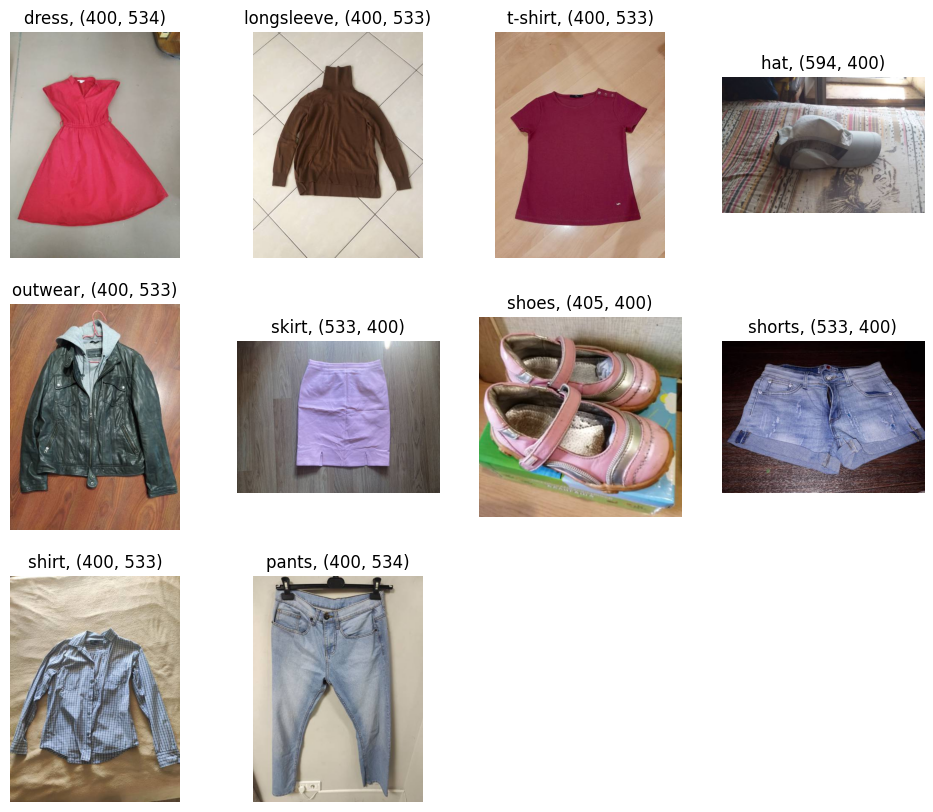

In [5]:
# display images
plt.figure(figsize=(12, 10))
for idx, (label, imgtoShow) in enumerate(imagePerClass.items()):
  # plot each Image
  ax = plt.subplot(3, 4, idx+1)
  plt.imshow(imgtoShow)
  plt.axis("off")
  plt.title(f"{label}, {imgtoShow.size}")

Count of training samples per class:



Text(0, 0.5, 'Count')

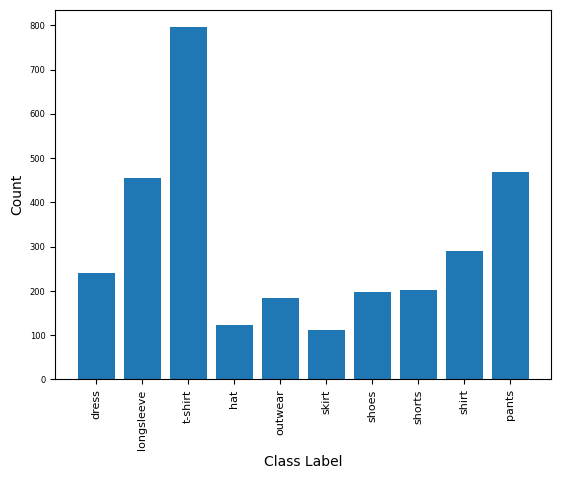

In [6]:
## Let's now Plot the Data Distribution of Training Data across Classes
print("Count of training samples per class:\n",)
countDataDist = pd.DataFrame({"label":countPerClass.keys(), "count":countPerClass.values()})
plt.bar(countDataDist["label"], countDataDist["count"])
plt.xlabel("Class Label", fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=6)
plt.ylabel("Count")

We can see that the class distribution is heavily imbalanced.
Ways to increase balance the data
* Under Sampling
* Over Sampling
* Fetch New Data
* Generate Synthetic Data using SMOTE (Not Prefered)
* Data Argumentation
* Synthetic data generation using Models like GANs

In [7]:
# loading the image Data set for Processing:
print('\nLoading Train Data...')
TrainData = tf.keras.utils.image_dataset_from_directory("clothing-dataset-small/train", shuffle=True)
ValData = tf.keras.utils.image_dataset_from_directory("clothing-dataset-small/validation", shuffle=True)
TestData = tf.keras.utils.image_dataset_from_directory("clothing-dataset-small/test", shuffle=True)


Loading Train Data...
Found 3068 files belonging to 10 classes.
Found 341 files belonging to 10 classes.
Found 372 files belonging to 10 classes.


In [8]:
# prepropcessing the Image Data:
height=128
width=128

data_preprocess = keras.Sequential(
    name="data_preprocess",
    layers=[
        layers.Resizing(height, width), # Shape Preprocessing
        layers.Rescaling(1.0/255), # Value Preprocessing
    ]
)


TrainData = TrainData.map(lambda x, y: (data_preprocess(x), y))
ValData = ValData.map(lambda x, y: (data_preprocess(x), y))
TestData = TestData.map(lambda x, y: (data_preprocess(x), y))

In [9]:
num_classes = 10
hidden_size_1 = 1024
hidden_size_2 = 256

model = keras.Sequential(
    name="model_ann",
    layers=[
        layers.Flatten(input_shape=(height, width, 3)), # alternatively, input_shape=next(iter(train_ds))[0].shape[1:]
        layers.Dense(units=hidden_size_1, activation='relu'), # hidden layer 1
        layers.Dense(units=hidden_size_2, activation='relu'), # hidden layer 2
        layers.Dense(units=num_classes, activation='softmax'), # output layer
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()

Model: "model_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 49152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      50,332,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,597,642 (193.01 MB)

 Trainable params: 50,597,642 (193.01 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
epochs = 10
model_fit = model.fit(TrainData, validation_data=ValData, epochs=epochs)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.1797 - loss: 34.5981 - val_accuracy: 0.3314 - val_loss: 2.6889
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.3328 - loss: 2.7852 - val_accuracy: 0.2258 - val_loss: 2.7786
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.3600 - loss: 2.3766 - val_accuracy: 0.2962 - val_loss: 2.3220
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.3868 - loss: 2.1835 - val_accuracy: 0.4194 - val_loss: 1.7021
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.4634 - loss: 1.6499 - val_accuracy: 0.4106 - val_loss: 1.9878
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.4880 - loss: 1.5842 - val_accuracy: 0.4663 - val_loss: 1.7614
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.5109 - loss: 1.5138 - val_accuracy: 0.4428 - val_loss: 1.7479
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.5260 - loss: 1.4785 - val_accuracy: 0.4282 

In [14]:
model_fit.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

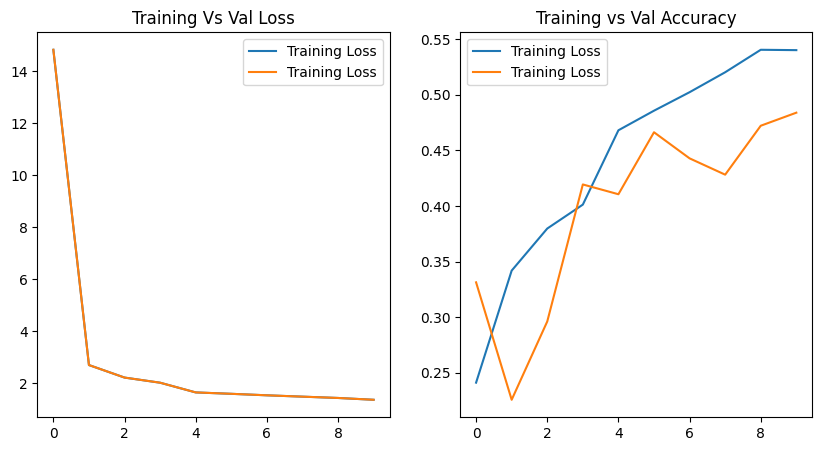

In [22]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))
ax[0].plot(model_fit.history["loss"], label="Training Loss")
ax[0].plot(model_fit.history["loss"], label="Training Loss")
ax[0].legend()
ax[0].set_title("Training Vs Val Loss")

ax[1].plot(model_fit.history["accuracy"], label="Training Loss")
ax[1].plot(model_fit.history["val_accuracy"], label="Training Loss")
ax[1].legend()
ax[1].set_title("Training vs Val Accuracy")

plt.show()

In [27]:
modelPreds = model.predict(TestData)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [32]:
print(modelPreds[0])
print(np.argmax(modelPreds[0]))

[0.00336655 0.01128384 0.36073127 0.03557    0.00124184 0.25019604
 0.0190323  0.07112125 0.14236203 0.10509491]
2
